In [1]:
# Cell 1: Imports
# These are the tools we'll use throughout the project.
import pandas as pd              # tables / dataframes
import numpy as np                # numerical arrays
import matplotlib.pyplot as plt   # plotting
import seaborn as sns             # nicer-looking plots

from rdkit import Chem            # parse molecules
from rdkit.Chem import Descriptors, Lipinski  # compute molecular properties

# Make plots show up inline in the notebook, with a clean style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("All imports successful")

Matplotlib is building the font cache; this may take a moment.


All imports successful


In [2]:
# Cell 2: Load the dataset
# pandas can read CSV files directly. The "df" name is conventional for "dataframe".
df = pd.read_csv("../data/delaney_solubility.csv")

# Show the dimensions (rows, columns)
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Show the first 5 rows
df.head()

Dataset shape: (1128, 10)
Columns: ['Compound ID', 'ESOL predicted log solubility in mols per litre', 'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area', 'measured log solubility in mols per litre', 'smiles']


,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


count    1128.000000
mean       -3.050102
std         2.096441
min       -11.600000
25%        -4.317500
50%        -2.860000
75%        -1.600000
max         1.580000
Name: measured log solubility in mols per litre, dtype: float64


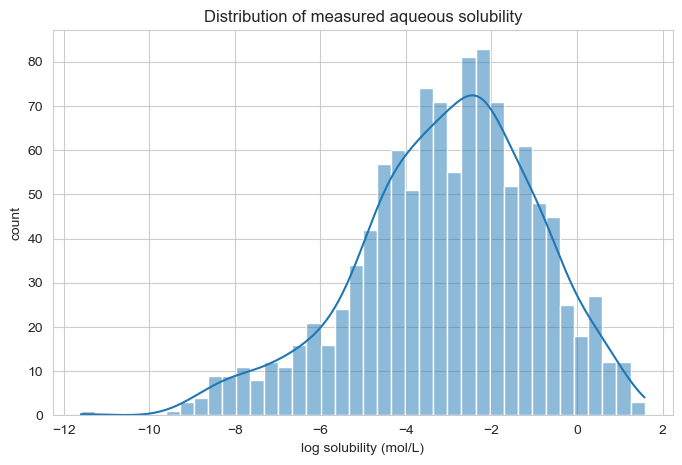

In [3]:
# Cell 3: Look at the target variable
# Our task: predict "measured log solubility in mols per litre"
# Negative values mean less soluble (e.g., -5 is much less soluble than -1)

target_col = "measured log solubility in mols per litre"

# Statistical summary
print(df[target_col].describe())

# Distribution plot
sns.histplot(df[target_col], bins=40, kde=True)
plt.xlabel("log solubility (mol/L)")
plt.ylabel("count")
plt.title("Distribution of measured aqueous solubility")
plt.show()

In [4]:
# Cell 4: Convert SMILES strings to RDKit Mol objects
# A "Mol" object is RDKit's internal representation of a molecule.
# Once we have a Mol, we can compute any chemical property from it.

# Apply Chem.MolFromSmiles to every SMILES string in the dataset.
# This adds a new column "mol" containing the parsed molecule.
df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)

# Sanity check: did any SMILES fail to parse?
n_failed = df["mol"].isna().sum()
print(f"Number of molecules that failed to parse: {n_failed}")
print(f"Total molecules in dataset: {len(df)}")

# Drop any rows where parsing failed (shouldn't be any for this dataset)
df = df.dropna(subset=["mol"]).reset_index(drop=True)
print(f"After cleaning: {len(df)} molecules")

Number of molecules that failed to parse: 0
Total molecules in dataset: 1128
After cleaning: 1128 molecules


In [5]:
# Cell 5: Compute molecular descriptors for every molecule
# Each function takes a Mol object and returns a single number.

def aromatic_proportion(mol):
    """Fraction of heavy atoms that are aromatic."""
    aromatic_atoms = sum(1 for atom in mol.GetAtoms() if atom.GetIsAromatic())
    total_atoms = mol.GetNumHeavyAtoms()  # excludes hydrogens
    return aromatic_atoms / total_atoms if total_atoms > 0 else 0

# Compute each feature for every molecule
df["MolWt"] = df["mol"].apply(Descriptors.MolWt)
df["LogP"] = df["mol"].apply(Descriptors.MolLogP)
df["NumRotatableBonds"] = df["mol"].apply(Lipinski.NumRotatableBonds)
df["AromaticProportion"] = df["mol"].apply(aromatic_proportion)

# Show the new columns alongside the target
df[["smiles", "MolWt", "LogP", "NumRotatableBonds", "AromaticProportion", 
    "measured log solubility in mols per litre"]].head(10)

,smiles,MolWt,LogP,NumRotatableBonds,AromaticProportion,measured log solubility in mols per litre
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,457.432,-3.10802,7,0.187500,-0.77
1,Cc1occc1C(=O)Nc2ccccc2,201.225,2.84032,2,0.733333,-3.30
2,CC(C)=CCCC(C)=CC(=O),152.237,2.87800,4,0.000000,-2.06
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,278.354,6.29940,0,1.000000,-7.87
4,c1ccsc1,84.143,1.74810,0,1.000000,-1.33
5,c2ccc1scnc1c2,135.191,2.29630,0,1.000000,-1.50
6,Clc1cc(Cl)c(c(Cl)c1)c2c(Cl)cccc2Cl,326.437,6.62060,1,0.705882,-7.32
7,CC12CCC3C(CCc4cc(O)ccc34)C2CCC1O,272.388,3.60920,0,0.300000,-5.03
8,ClC4=C(Cl)C5(Cl)C3C1CC(C2OC12)C3C4(Cl)C5(Cl)Cl,380.913,4.48140,0,0.000000,-6.29
9,COc5cc4OCC3Oc2c1CC(Oc1ccc2C(=O)C3c4cc5OC)C(C)=C,394.423,3.70330,3,0.413793,-4.42


In [6]:
# Cell 6: Prepare features and target for ML
# X: the input matrix (n_samples x n_features)
# y: the target vector (n_samples,)

feature_cols = ["MolWt", "LogP", "NumRotatableBonds", "AromaticProportion"]
target_col = "measured log solubility in mols per litre"

X = df[feature_cols].values
y = df[target_col].values

print(f"X shape: {X.shape}")  # (n_molecules, 4)
print(f"y shape: {y.shape}")  # (n_molecules,)
print(f"\nFirst 3 rows of X:\n{X[:3]}")
print(f"\nFirst 3 values of y: {y[:3]}")

X shape: (1128, 4)
y shape: (1128,)

First 3 rows of X:
[[ 4.57432000e+02 -3.10802000e+00  7.00000000e+00  1.87500000e-01]
 [ 2.01225000e+02  2.84032000e+00  2.00000000e+00  7.33333333e-01]
 [ 1.52237000e+02  2.87800000e+00  4.00000000e+00  0.00000000e+00]]

First 3 values of y: [-0.77 -3.3  -2.06]


In [7]:
# Cell 7: Split into training and test sets
from sklearn.model_selection import train_test_split

# 80% for training, 20% for testing
# random_state=42 makes the split reproducible (same split every run)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training set: {X_train.shape[0]} molecules")
print(f"Test set:     {X_test.shape[0]} molecules")

Training set: 902 molecules
Test set:     226 molecules


In [8]:
# Cell 8: Train Linear Regression (reproducing Delaney 2004)
from sklearn.linear_model import LinearRegression

# Create the model
lr_model = LinearRegression()

# Fit on training data only
lr_model.fit(X_train, y_train)

# Make predictions on both train and test sets
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

# Show the learned coefficients (this is what makes LR interpretable)
print("Linear Regression coefficients:")
for feat, coef in zip(feature_cols, lr_model.coef_):
    print(f"  {feat:20s}: {coef:+.4f}")
print(f"  {'intercept':20s}: {lr_model.intercept_:+.4f}")

Linear Regression coefficients:
  MolWt               : -0.0062
  LogP                : -0.7551
  NumRotatableBonds   : -0.0088
  AromaticProportion  : -0.3521
  intercept           : +0.2223


In [9]:
# Cell 9: Evaluate Linear Regression performance
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

def evaluate_model(name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    """Print RMSE, R², MAE for both training and test sets."""
    print(f"\n=== {name} ===")
    print(f"{'Metric':<10} {'Train':>10} {'Test':>10}")
    print("-" * 32)
    
    rmse_train = np.sqrt(mean_squared_error(y_train_true, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
    print(f"{'RMSE':<10} {rmse_train:>10.4f} {rmse_test:>10.4f}")
    
    r2_train = r2_score(y_train_true, y_train_pred)
    r2_test = r2_score(y_test_true, y_test_pred)
    print(f"{'R²':<10} {r2_train:>10.4f} {r2_test:>10.4f}")
    
    mae_train = mean_absolute_error(y_train_true, y_train_pred)
    mae_test = mean_absolute_error(y_test_true, y_test_pred)
    print(f"{'MAE':<10} {mae_train:>10.4f} {mae_test:>10.4f}")

evaluate_model("Linear Regression", y_train, y_train_pred_lr, y_test, y_test_pred_lr)


=== Linear Regression ===
Metric          Train       Test
--------------------------------
RMSE           0.9830     1.1129
R²             0.7756     0.7380
MAE            0.7659     0.8327


In [10]:
# Cell 10: Train Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# n_estimators=100 means 100 decision trees in the forest
# random_state=42 makes it reproducible
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Fit on training data
rf_model.fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Feature importance (which features mattered most?)
print("Random Forest feature importances:")
for feat, imp in sorted(zip(feature_cols, rf_model.feature_importances_), 
                         key=lambda x: -x[1]):
    print(f"  {feat:20s}: {imp:.4f}")

Random Forest feature importances:
  LogP                : 0.8293
  MolWt               : 0.1323
  AromaticProportion  : 0.0215
  NumRotatableBonds   : 0.0170


In [11]:
# Cell 11: Evaluate Random Forest and compare with Linear Regression
evaluate_model("Random Forest", y_train, y_train_pred_rf, y_test, y_test_pred_rf)
evaluate_model("Linear Regression", y_train, y_train_pred_lr, y_test, y_test_pred_lr)


=== Random Forest ===
Metric          Train       Test
--------------------------------
RMSE           0.2850     0.8326
R²             0.9811     0.8533
MAE            0.2081     0.5837

=== Linear Regression ===
Metric          Train       Test
--------------------------------
RMSE           0.9830     1.1129
R²             0.7756     0.7380
MAE            0.7659     0.8327


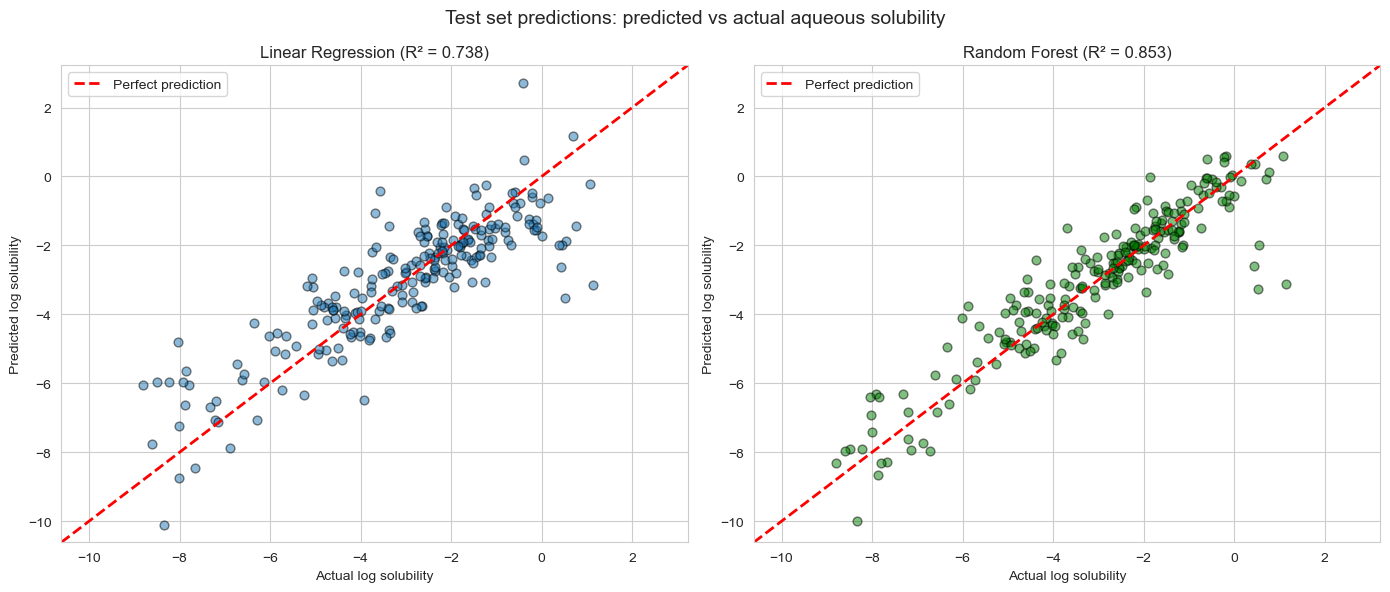

Plot saved to results/predicted_vs_actual.png


In [12]:
# Cell 12: Predicted vs Actual scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Determine common axis range so both plots are comparable
y_min = min(y_test.min(), y_test_pred_lr.min(), y_test_pred_rf.min()) - 0.5
y_max = max(y_test.max(), y_test_pred_lr.max(), y_test_pred_rf.max()) + 0.5

# --- Left plot: Linear Regression ---
axes[0].scatter(y_test, y_test_pred_lr, alpha=0.5, edgecolors="k", s=40)
axes[0].plot([y_min, y_max], [y_min, y_max], "r--", lw=2, label="Perfect prediction")
axes[0].set_xlabel("Actual log solubility")
axes[0].set_ylabel("Predicted log solubility")
axes[0].set_title(f"Linear Regression (R² = {r2_score(y_test, y_test_pred_lr):.3f})")
axes[0].legend()
axes[0].set_xlim(y_min, y_max)
axes[0].set_ylim(y_min, y_max)

# --- Right plot: Random Forest ---
axes[1].scatter(y_test, y_test_pred_rf, alpha=0.5, edgecolors="k", s=40, color="green")
axes[1].plot([y_min, y_max], [y_min, y_max], "r--", lw=2, label="Perfect prediction")
axes[1].set_xlabel("Actual log solubility")
axes[1].set_ylabel("Predicted log solubility")
axes[1].set_title(f"Random Forest (R² = {r2_score(y_test, y_test_pred_rf):.3f})")
axes[1].legend()
axes[1].set_xlim(y_min, y_max)
axes[1].set_ylim(y_min, y_max)

plt.suptitle("Test set predictions: predicted vs actual aqueous solubility", fontsize=14)
plt.tight_layout()

# Save the figure to the results/ folder for the README
plt.savefig("../results/predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to results/predicted_vs_actual.png")

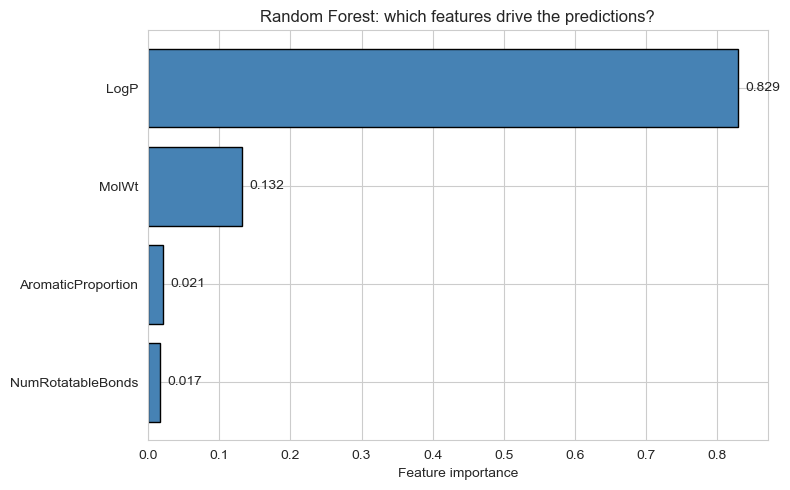

Plot saved to results/feature_importance.png


In [13]:
# Cell 13: Feature importance visualization
fig, ax = plt.subplots(figsize=(8, 5))

# Get feature importances from random forest, sort descending
importances = rf_model.feature_importances_
sorted_indices = np.argsort(importances)[::-1]
sorted_features = [feature_cols[i] for i in sorted_indices]
sorted_importances = importances[sorted_indices]

# Bar plot
bars = ax.barh(sorted_features, sorted_importances, color="steelblue", edgecolor="black")
ax.set_xlabel("Feature importance")
ax.set_title("Random Forest: which features drive the predictions?")
ax.invert_yaxis()  # most important at top

# Add value labels on bars
for bar, imp in zip(bars, sorted_importances):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
            f"{imp:.3f}", va="center")

plt.tight_layout()
plt.savefig("../results/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to results/feature_importance.png")

In [14]:
# Cell 14: Save metrics to a CSV file for the README
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "Train RMSE": [
        np.sqrt(mean_squared_error(y_train, y_train_pred_lr)),
        np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
    ],
    "Test RMSE": [
        np.sqrt(mean_squared_error(y_test, y_test_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
    ],
    "Train R²": [
        r2_score(y_train, y_train_pred_lr),
        r2_score(y_train, y_train_pred_rf)
    ],
    "Test R²": [
        r2_score(y_test, y_test_pred_lr),
        r2_score(y_test, y_test_pred_rf)
    ],
    "Test MAE": [
        mean_absolute_error(y_test, y_test_pred_lr),
        mean_absolute_error(y_test, y_test_pred_rf)
    ]
})

# Round for readability
results_df = results_df.round(3)

# Save and display
results_df.to_csv("../results/model_comparison.csv", index=False)
print("Results saved to results/model_comparison.csv\n")
print(results_df.to_string(index=False))

Results saved to results/model_comparison.csv

            Model  Train RMSE  Test RMSE  Train R²  Test R²  Test MAE
Linear Regression       0.983      1.113     0.776    0.738     0.833
    Random Forest       0.285      0.833     0.981    0.853     0.584
